In [1]:
import pandas as pd

df = pd.read_csv("Exam_Score_Prediction.csv")
df.head()


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [2]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
# Load Dataset

df = pd.read_csv("Exam_Score_Prediction.csv")

df.head()


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [4]:
# Check data structure

df.info()

# Check missing values
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  str    
 3   course            20000 non-null  str    
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  str    
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  str    
 9   study_method      20000 non-null  str    
 10  facility_rating   20000 non-null  str    
 11  exam_difficulty   20000 non-null  str    
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), str(7)
memory usage: 2.0 MB


student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [5]:
df.isnull().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [6]:
# Create Score Category

def categorize(score):
    if score <= 40:
        return "Low"
    elif score <= 70:
        return "Medium"
    else:
        return "High"

df["score_category"] = df["exam_score"].apply(categorize)

df[["exam_score", "score_category"]].head()


,exam_score,score_category
0,58.9,Medium
1,54.8,Medium
2,90.3,High
3,29.7,Low
4,43.7,Medium


In [7]:
# Select features (X)
X = df.drop(["student_id", "exam_score", "score_category"], axis=1)

# Target variable (y)
y = df["exam_score"]

X.head()


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate


In [8]:
X = pd.get_dummies(X, drop_first=True)

X.head()


,age,study_hours,class_attendance,sleep_hours,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,...,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium,exam_difficulty_hard,exam_difficulty_moderate
0,17,2.78,92.9,7.4,True,False,False,False,False,False,...,False,True,False,False,False,False,True,False,True,False
1,23,3.37,64.8,4.6,False,True,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
2,22,7.88,76.8,8.5,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,20,0.67,48.4,5.8,False,True,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True
4,20,0.89,71.6,9.8,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (16000, 23)
Testing Data: (4000, 23)


In [10]:
from sklearn.ensemble import RandomForestRegressor


In [11]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("Model Training Completed ✅")


Model Training Completed ✅


In [12]:
y_pred = model.predict(X_test)

y_pred[:5]


array([35.98598, 71.459  , 57.192  , 95.497  , 84.917  ])

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 8.571973665000002
MSE: 112.95653643565235
R2 Score: 0.6842116908779627


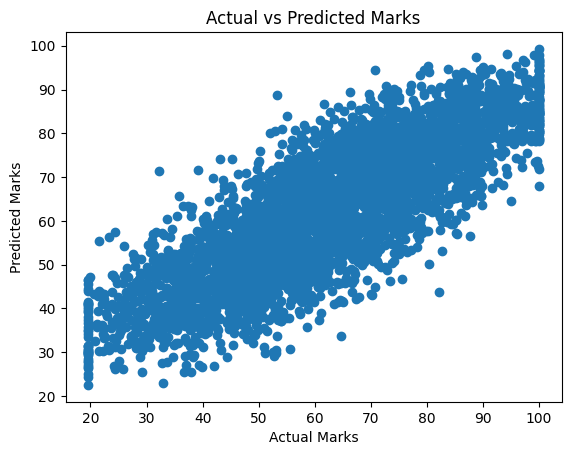

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.show()


In [15]:
print(X.columns)


Index(['age', 'study_hours', 'class_attendance', 'sleep_hours', 'gender_male',
       'gender_other', 'course_b.sc', 'course_b.tech', 'course_ba',
       'course_bba', 'course_bca', 'course_diploma', 'internet_access_yes',
       'sleep_quality_good', 'sleep_quality_poor', 'study_method_group study',
       'study_method_mixed', 'study_method_online videos',
       'study_method_self-study', 'facility_rating_low',
       'facility_rating_medium', 'exam_difficulty_hard',
       'exam_difficulty_moderate'],
      dtype='str')


In [16]:
# Example student input

new_data = {
    "age": 20,
    "study_hours": 5,
    "class_attendance": 80,
    "sleep_hours": 7,
    "facility_rating": 3,
    
    # For categorical columns (after get_dummies)
    "gender_male": 1,
    "course_bba": 0,
    "course_btech": 1,
    "internet_access_yes": 1,
    "sleep_quality_good": 1,
    "study_method_self-study": 1,
    "exam_difficulty_moderate": 1
}


In [17]:
new_df = pd.DataFrame([new_data])


In [19]:
# Raw input (before dummy conversion)

new_student = pd.DataFrame({
    "age": [20],
    "gender": ["male"],
    "course": ["btech"],
    "study_hours": [5],
    "class_attendance": [80],
    "internet_access": ["yes"],
    "sleep_hours": [7],
    "sleep_quality": ["good"],
    "study_method": ["self-study"],
    "facility_rating": [3],
    "exam_difficulty": ["moderate"]
})

# Convert same as training
new_student = pd.get_dummies(new_student)

# Match training columns
new_student = new_student.reindex(columns=X.columns, fill_value=0)

# Predict
prediction = model.predict(new_student)

print("Predicted Marks:", prediction[0])


Predicted Marks: 80.74699999999997


In [20]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))


In [22]:
import pickle

# Save model again
pickle.dump(model, open("model.pkl", "wb"))

# Save feature column names
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))
